# Air Quality and Health Impact Classification

# Problem Statement

Air pollution is a leading contributor to respiratory and cardiovascular diseases worldwide. Rising pollution levels increase the burden on healthcare systems and public health infrastructure.

The objective of this project is to build a machine learning model capable of classifying the severity of health impacts based on environmental pollution indicators and healthcare statistics.

### Machine Learning Framing
- **Target Variable:** HealthImpactClass
- **Problem Type:** Multiclass Classification
- **Classes:** 0–4 representing increasing severity of health impact.

### Business Objective
- Enable early detection of dangerous pollution conditions
- Support healthcare planning and hospital resource allocation
- Assist policymakers in identifying high-risk environmental patterns

# Importing Required Libraries
The following libraries are used for:
- Data manipulation: NumPy, Pandas
- Visualization: Matplotlib, Seaborn
- Modeling & evaluation: Scikit-learn
- Handling class imbalance: Imbalanced-learn (SMOTE)

Warnings are suppressed to keep the notebook output clean and readable.

In [1]:
# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Imbalance Handling
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Data Loading

The dataset is loaded using Pandas. Initial rows are displayed to verify successful loading and inspect feature structure.

In [2]:
df = pd.read_csv("air_quality_health_impact_data.csv")
df.head()

,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


### Initial Data Inspection - Observations:

- The dataset contains environmental pollution indicators, meteorological data, and healthcare statistics.
- Each row represents an environmental observation linked to health outcomes.
- The target variable `HealthImpactClass` represents the severity of health impact on a scale from 0 to 4.
- All features appear numeric, simplifying preprocessing and model training.

# Data Overview & Schema Validation

In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), int64(4)
memory usage:

(5811, 15)

### Observations:
- Dataset contains **5,811 records and 15 features**
- No missing values detected
- All columns are numeric, which simplifies preprocessing.
- HealthImpactClass is stored as float but represents categorical labels.
- RecordID is an identifier and should not be used for model training.

This confirms the dataset is **clean and ML-ready**.

# Statistical Analysis

Descriptive statistics provide insight into feature distributions
and confirm realistic value ranges.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RecordID,5811.0,2906.000000,1677.635538,1.000000,1453.500000,2906.000000,4358.500000,5811.000000
AQI,5811.0,248.438476,144.777638,0.005817,122.951293,249.127841,373.630668,499.858837
PM10,5811.0,148.654997,85.698500,0.015848,75.374954,147.634997,222.436759,299.901962
PM2_5,5811.0,100.223714,58.096612,0.031549,49.435171,100.506337,151.340260,199.984965
NO2,5811.0,102.293445,57.713175,0.009625,53.538538,102.987736,151.658516,199.980195
SO2,5811.0,49.456838,28.530329,0.011023,24.887264,49.530165,73.346617,99.969561
O3,5811.0,149.312431,86.534240,0.001661,73.999665,149.559871,223.380126,299.936812
Temperature,5811.0,14.975500,14.483067,-9.990998,2.481500,14.942428,27.465374,39.963434
Humidity,5811.0,54.776853,26.020786,10.001506,31.995262,54.543904,77.641639,99.997493
WindSpeed,5811.0,9.989177,5.776950,0.002094,4.952343,10.051742,14.971840,19.999139


### Statistical Summary – Observations:
- Pollution indicators (AQI, PM10, PM2.5) show wide variability, indicating diverse pollution levels
- Temperature includes negative values, suggesting winter conditions
- HealthImpactScore appears highly concentrated near 100, suggesting skewness in health impact severity.
- Target variable is highly imbalanced, with most samples in class 0

These observations justify:
- Outlier inspection
- Scaling of numerical features
- Explicit class imbalance handling

# Missing & Duplicate Value Check

In [5]:
# Missing values
df.isnull().sum()

# Duplicate rows
df.duplicated().sum()

0

### Observations:

- No missing values detected across any feature
- No duplicate records found

This ensures no bias or redundancy is introduced into the model.

# Data Cleaning & Validation

## Data Cleaning

Basic validation applied:
- Removed invalid negative values
- Ensured humidity within 0–100 range

In [6]:
pollution_cols = ['AQI','PM10','PM2_5','NO2','SO2','O3']
health_cols = ['RespiratoryCases','CardiovascularCases','HospitalAdmissions']

for col in pollution_cols + health_cols:
    df = df[df[col] >= 0]

df = df[(df['Humidity'] >= 0) & (df['Humidity'] <= 100)]
df = df[df['WindSpeed'] >= 0]

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (5811, 15)


### Data Cleaning -  Observations:
The following Basic domain validation rules are applied to ensure data realism and remove invalid entries:

- Pollution and health indicators cannot be negative
- Humidity must lie between 0–100%
- Wind speed must be non-negative

These rules ensure **real-world plausibility** and data integrity.

## Outlier Removal

The IQR method is applied to remove extreme outliers
and reduce noise for model stability.

In [7]:
numeric_cols = df.drop(columns=['HealthImpactClass']).select_dtypes(include='number').columns
def remove_outliers_iqr(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return data[(data[column] >= lower) & (data[column] <= upper)]

df.shape

(5811, 15)

### Outlier Detection & Treatment - Observations:
The Interquartile Range (IQR) method was used to identify extreme values.
Outlier removal helps:
- Reduce noise
- Improve model generalization
- Stabilize distance-based algorithms

Post-cleaning, dataset size remains unchanged, indicating minimal extreme noise.

# Exploratory Data Analysis

## Pollution Distribution Histogram

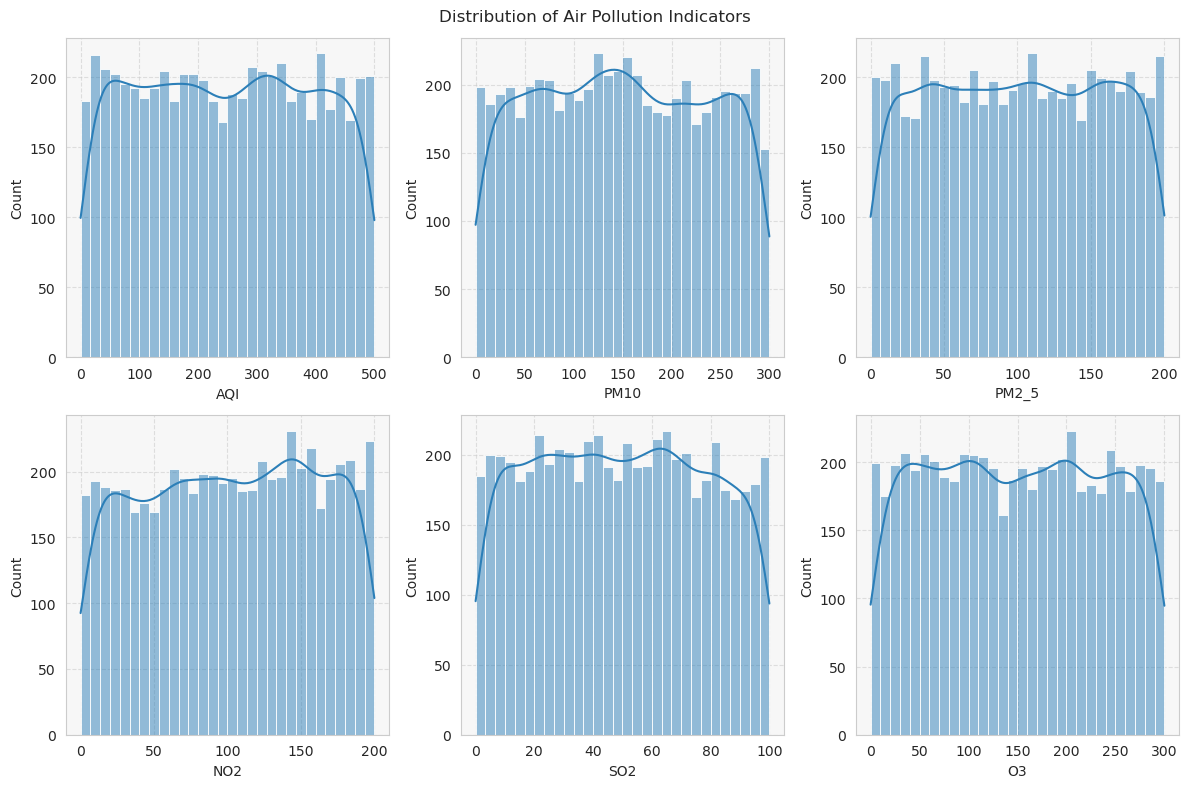

In [8]:
pollution_cols = ['AQI','PM10','PM2_5','NO2','SO2','O3']

fig, axes = plt.subplots(2, 3, figsize=(12,8))

for col, ax in zip(pollution_cols, axes.flatten()):
    sns.histplot(df[col], bins=30, kde=True, color='#2C7FB8', ax=ax)
    ax.set_facecolor('#f7f7f7')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle("Distribution of Air Pollution Indicators")
plt.tight_layout()
plt.show()

### Observations:

The histograms reveal the distribution of major air pollution indicators.

Key insights:

- AQI values span a wide range, indicating varying air quality conditions.
- PM10 and PM2.5 concentrations show moderately symmetric distributions.
- Gaseous pollutants such as NO2, SO2, and O3 show dispersed distributions across observations.

These distributions indicate variability in pollution conditions, which may influence health impact severity.

## Boxplots for Outliers

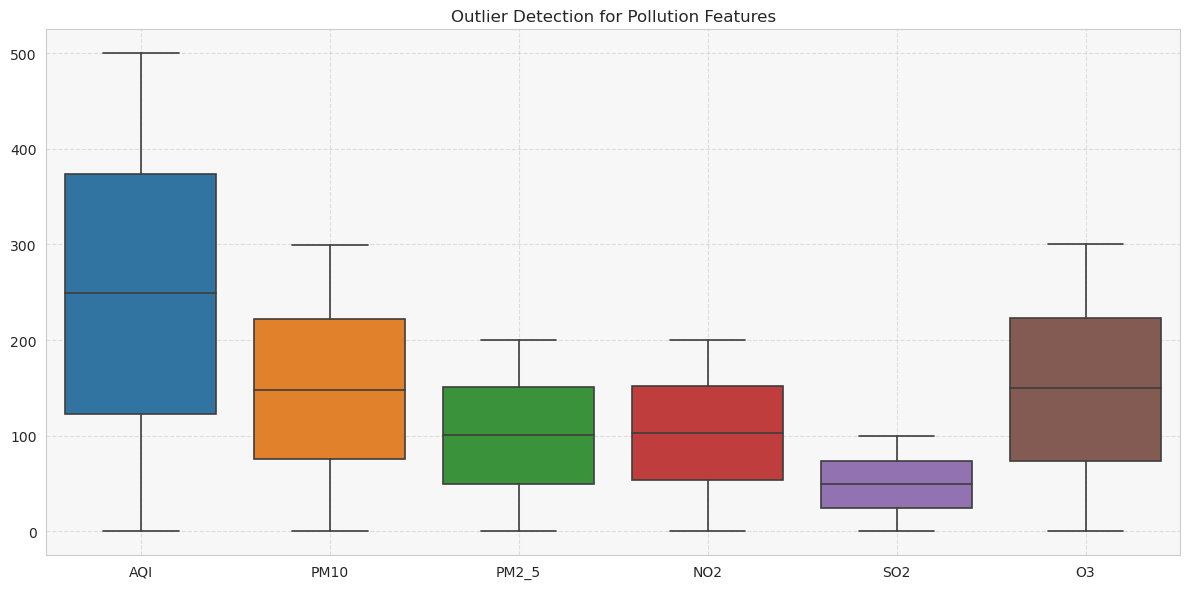

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[pollution_cols], palette='tab10', linewidth=1.2)

ax = plt.gca()
ax.set_facecolor('#f7f7f7')
ax.grid(True, linestyle='--', alpha=0.6)

plt.title("Outlier Detection for Pollution Features")

plt.tight_layout()
plt.show()

### Observations:

Boxplots highlight potential outliers in pollution indicators.

Key observations:

- Some extreme values appear in AQI and PM10, indicating severe pollution events.
- PM2.5 and NO2 show moderate spread with occasional high values.
- Outliers may represent real environmental events rather than measurement errors.

Tree-based models such as Random Forest are generally robust to outliers.

## Class Distribution

The target variable is highly imbalanced,
requiring imbalance handling techniques.

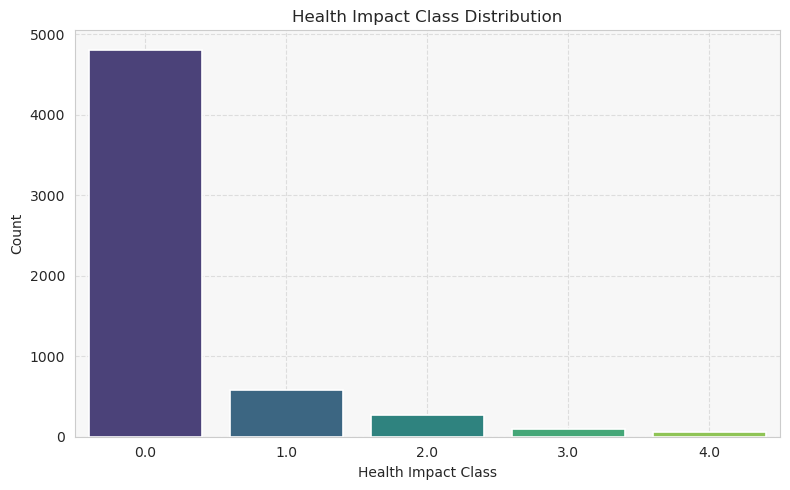

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['HealthImpactClass'], palette='viridis', linewidth=1.2)

ax = plt.gca()
ax.set_facecolor('#f7f7f7')
ax.grid(True, linestyle='--', alpha=0.6)

plt.title("Health Impact Class Distribution")
plt.xlabel("Health Impact Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Target Variable Distribution -  Observations:
- Severe class imbalance observed
- Class 0 dominates the dataset (~83%)
- Minority classes represent critical health conditions

This imbalance necessitates techniques such as **SMOTE** to prevent biased learning.

## Correlation Analysis

Correlation heatmap identifies feature relationships
and potential multicollinearity.## Correlation Analysis

Correlation heatmap identifies feature relationships
and potential multicollinearity.

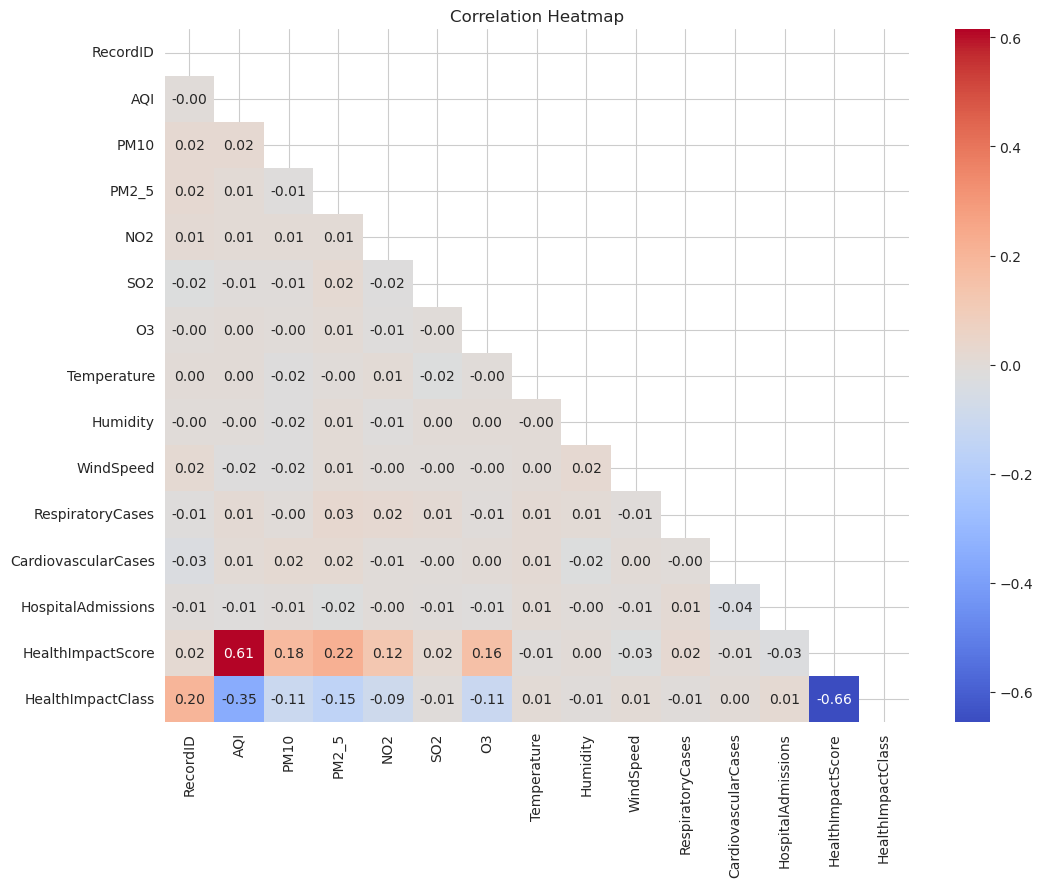

In [11]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,9))
sns.heatmap(corr, mask=mask, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Observations:

The correlation heatmap reveals relationships between environmental and health indicators.

Key insights:

- Strong correlations exist between pollution variables such as AQI, PM10, and PM2.5.
- Healthcare indicators show moderate correlations with pollution levels.
- No extremely high correlations (>0.9) were detected that would require feature removal.

Tree-based models can effectively handle correlated features.

# Feature Scaling & Split

## Train-Test Split and Scaling

Stratified split ensures class proportion consistency.
StandardScaler normalizes feature magnitudes.

In [12]:
X = df.drop(columns=['HealthImpactClass', 'RecordID'])
y = df['HealthImpactClass']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Observations:
- Stratified split preserves class proportions
- StandardScaler ensures equal feature contribution
- Scaling performed **before SMOTE** because SMOTE relies on nearest neighbor calculations. Feature scaling ensures distance calculations are meaningful.

# Class Imbalance Handling using SMOTE

SMOTE (Synthetic Minority Oversampling Technique) is applied only on the
training data to generate synthetic samples for minority classes.
This helps mitigate class imbalance without causing data leakage.

In [13]:
# Applying SMOTE on scaled training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Verifying class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Class distribution after SMOTE:
HealthImpactClass
0.0    3846
1.0    3846
4.0    3846
3.0    3846
2.0    3846
Name: count, dtype: int64


### Observations:

SMOTE synthetically generates minority class samples:
- Applied only to training data
- Prevents overfitting to majority class
- Improves minority class recall

Post-SMOTE, all classes are perfectly balanced.

# Model Training Strategy

Multiple machine learning algorithms were trained and evaluated to identify the best performing model:

- Logistic Regression
- Random Forest
- Gradient Boosting
- Support Vector Machine (SVM)

Accuracy was used as the initial evaluation metric.

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_resampled, y_train_resampled)
    preds = model.predict(X_test_scaled)
    results[name] = accuracy_score(y_test, preds)

In [15]:
results_df = pd.DataFrame(results.items(), columns=["Model", "Accuracy"])
results_df.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Random Forest,0.955288
2,Gradient Boosting,0.932932
3,SVM,0.872743
0,Logistic Regression,0.543422


In [16]:
results

{'Logistic Regression': 0.5434221840068788,
 'Random Forest': 0.9552880481513327,
 'Gradient Boosting': 0.9329320722269991,
 'SVM': 0.8727429062768701}

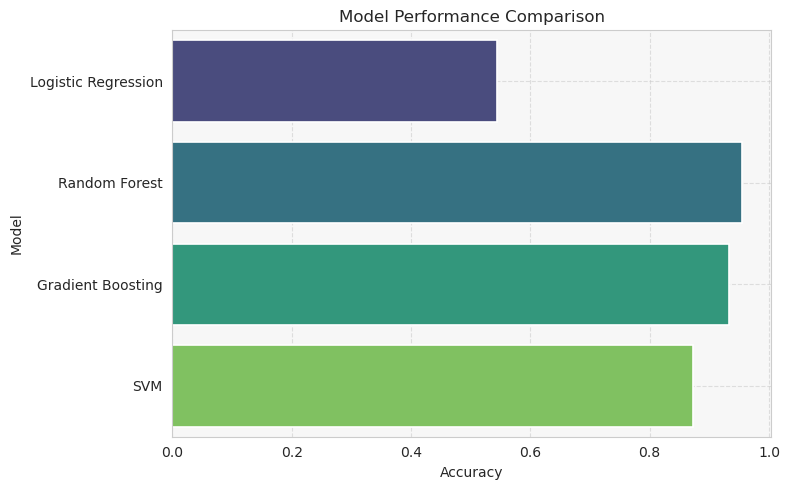

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(data=results_df, x="Accuracy", y="Model", palette="viridis", linewidth=1.2)

ax = plt.gca()
ax.set_facecolor('#f7f7f7')
ax.grid(True, linestyle='--', alpha=0.6)

plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

### Observations:

The model comparison chart shows the performance of each classifier.

Key insights:

- Random Forest achieved the highest accuracy among all models.
- Gradient Boosting also performed strongly.
- Logistic Regression performed significantly worse due to non-linear relationships in the dataset.
- SVM performed well but required higher computational cost.

Based on these results, Random Forest was selected for further hyperparameter tuning.

## Hyperparameter Optimization

GridSearchCV is used to fine-tune the Random Forest model.

In [23]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_resampled, y_train_resampled)
best_rf = grid.best_estimator_

In [24]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### Observations:

GridSearchCV was used to:
- Improve model generalization
- Control tree depth and overfitting
- Optimize ensemble size

5-fold cross-validation ensures robust performance estimation.

## Model Evaluation

Random Forest achieved the highest accuracy.
However, minority class recall remains low,
indicating imbalance challenges.

In [20]:
final_preds = best_rf.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, final_preds))
print(classification_report(y_test, final_preds))

Accuracy: 0.9552880481513327
              precision    recall  f1-score   support

         0.0       0.96      0.99      0.98       962
         1.0       0.97      0.89      0.93       116
         2.0       0.92      0.80      0.85        55
         3.0       0.83      0.53      0.65        19
         4.0       0.00      0.00      0.00        11

    accuracy                           0.96      1163
   macro avg       0.74      0.64      0.68      1163
weighted avg       0.95      0.96      0.95      1163



### Observations:
The Random Forest model achieved high overall accuracy.

However:

- Performance is strongest for the majority class (Class 0).
- Recall decreases for minority classes.
- Class 4 has extremely low recall due to very limited samples.

This highlights the challenge of detecting rare events in imbalanced datasets.

## Confusion Matrix

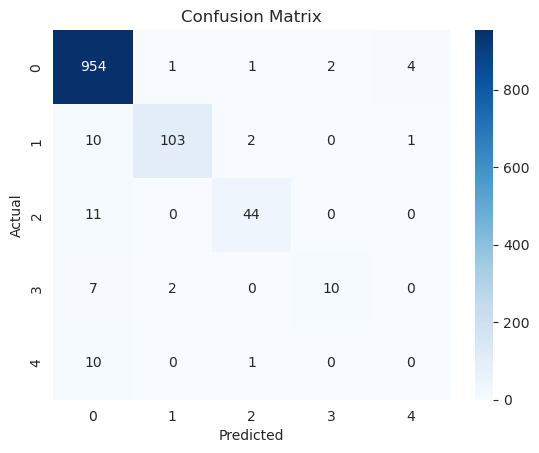

In [21]:
sns.heatmap(confusion_matrix(y_test, final_preds),
            annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Confusion Matrix Interpretation - Observations:

The confusion matrix illustrates prediction performance across all classes.

Observations:

- Most majority class samples are correctly classified.
- Some minority class instances are misclassified as lower severity levels.
- Class 4 predictions remain difficult due to limited training samples.

Improving minority class detection remains an area for future improvement.

In [22]:
import joblib
import os

# Create model directory if it doesn't exist
os.makedirs("model", exist_ok=True)

# Save trained model
joblib.dump(best_rf, "model/random_forest.pkl")

# Save fitted scaler
joblib.dump(scaler, "model/scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


## Conclusion

This project demonstrates a complete machine learning pipeline for predicting health impact severity based on air pollution indicators.

Key contributions include:

- Comprehensive exploratory data analysis
- Data validation and cleaning
- Handling class imbalance using SMOTE
- Training and comparing multiple machine learning models
- Hyperparameter tuning using GridSearchCV

Random Forest achieved the best performance with approximately 95% accuracy. However, the model struggles with extremely rare classes, indicating that future work should focus on improving minority class detection.

Potential improvements:
- Cost-sensitive learning
- Ensemble stacking
- Deep learning models
- Feature engineering using pollution indices